## ITI113 MLOps — Team 04: Credit Card Fraud Detection
## M06 — Final Model B (Linear/Neural) Training
### Vanitha — Linear/Neural Pipeline Track (Logistic Regression + MLP)

**Objective:** Build, tune, and log the final Linear/Neural mathematical frameworks using the
feature matrix engineered in `team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb`, and log
both to MLflow for experiment tracking per the team's MLOps infrastructure (Section 4.2 of the
proposal).

**Actionable deliverables & execution criteria (this notebook):**
- **Hyperparameter search** — Section 4a, `GridSearchCV` (Logistic Regression) and
  `RandomizedSearchCV` (MLP) against a validation-only fold, selecting the configuration each
  final model is trained with below.
- **Train Regularized Logistic Regression (L2) and Multi-Layer Perceptron (MLP) final model
  candidates** — Sections 5-6, each trained with the tuned hyperparameters, evaluated, and
  logged to MLflow as a separate run.
- **Fine-grained operational decision threshold tuning** — Section 8, scanning every threshold
  produced by the validation PR curve (not a coarse fixed grid), with the F1-optimal threshold
  logged back to MLflow for both models.
- **Log pipeline artifacts and final model performance metrics in MLflow** — params,
  validation/test metrics, confusion-matrix counts, the fitted model, the feature manifest,
  threshold-scan artifacts, and key figures are all logged per run (Sections 4a, 5, 6, 8, 9).
- **Register the final selected model** — Section 11c, with a registry description and a
  dynamically-set alias in the MLflow Model Registry.

**Scope for this milestone (per proposal Section 7 — Final Model Tuning & Production
Deployment):** hyperparameter-tuned Model B candidates, PR-AUC-first evaluation, fine-grained
threshold tuning, and registration of the final selected model in MLflow. This supersedes the
earlier fixed-hyperparameter pass produced for the Milestone Progress Check (16 Aug 2026).
SHAP-based explainability (M09) and production endpoint deployment remain separate, ongoing
deliverables.



In [2]:
# ============================================================
# 1. Configuration, Imports and Reproducibility
# ============================================================
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import warnings
import json
import os
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
import boto3
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import PredefinedSplit, GridSearchCV, RandomizedSearchCV
import statsmodels.api as sm
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, precision_recall_curve,
    ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'is_fraud'
# Restarted at 1.0 for the Final Model Tuning phase (proposal Section 7) — distinct from
# the earlier fixed-hyperparameter baseline versioning used for the Milestone Progress Check.
MODEL_VERSION = '1.0'
MILESTONE = 'M06'

# ---- Identity — declared first; everything below depends on these two values ----
# Same team-standard identity used in the M01 EDA and M03 feature-engineering notebooks.
# NOTE: this was previously 'S401' (uppercase) here — S3 keys are case-sensitive and M01/M03
# both upload under lowercase 's401', so the uppercase value silently pointed Section 2's S3
# read at a key that was never actually written to. Fixed to match.
TEAM_ID = 'team04'
STUDENT_ID = 's401'

# ---- Resolve the SageMaker execution role and region ----
# Same pattern used in the M01 EDA and M03 feature-engineering notebooks. Only succeeds
# inside a SageMaker Studio / Notebook Instance execution context; the except branch keeps
# this cell runnable outside SageMaker too.
try:
    import sagemaker
    sess = sagemaker.Session()
    region = sess.boto_region_name
    role = sagemaker.get_execution_role()
except Exception as e:
    region = boto3.Session().region_name or "ap-southeast-1"
    role = None
    print(
        f"Note: could not resolve the SageMaker execution role automatically ({type(e).__name__}). "
        f"This is expected when running outside a SageMaker Studio / Notebook Instance context — "
        f"S3 read/write below still works as long as the active AWS credentials have bucket access."
    )

s3 = boto3.client("s3", region_name=region)

# ============================================================
# Project storage configuration — same S3 project-root pattern as the M01 EDA and M03
# feature-engineering notebooks (copied from M03's Section 1 and adapted). ARTIFACT_DIR
# stays './artifacts' — the shared local convention both M03 and this notebook already
# read/write m03_*/vanitha_Model_B_* files through; S3 is layered on top of it here, not a
# replacement for it.
# ============================================================
S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

# S3_FE_OUTPUT_URI is where M03 (v1.7+) uploads m03_*.parquet / m03_*.joblib / m03_*.json —
# Section 2 below reads from it. S3_M06_OUTPUT_URI mirrors the same convention for this
# notebook's own outputs (declared for parity with the M01/M03 configs, which forward-declare
# it the same way; not yet wired to an upload call below).
S3_FE_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/feature_engineering/"
S3_M06_OUTPUT_URI = S3_BUCKET_URI + STUDENT_ID + "/processed/m06/"

ARTIFACT_DIR = Path('./artifacts')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def s3_join(prefix, *parts):
    """Safely join an S3 URI/prefix with one or more path components."""
    return prefix.rstrip("/") + "/" + "/".join(str(part).strip("/") for part in parts)


def parse_s3_uri(uri):
    p = urlparse(uri)
    if p.scheme != "s3" or not p.netloc:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return p.netloc, p.path.lstrip("/")


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover — identical to the
    helper in the M01 EDA and M03 feature-engineering notebooks."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.download_file(bucket, key, str(local_path))
        print(f"Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path

        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\n"
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        s3.upload_file(str(local_path), bucket, key)
        print(f"Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


def load_json_s3_or_local(s3_uri, local_path):
    local_path = download_s3_to_local(s3_uri, local_path)
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)


print(f'Artifact directory              : {ARTIFACT_DIR.resolve()}')
print(f'S3 feature-engineering source   : {S3_FE_OUTPUT_URI}')
print(f'S3 M06 output directory         : {S3_M06_OUTPUT_URI}')

# Explicit pip requirements for every mlflow.sklearn.log_model() call below — MLflow's
# automatic inference failed in this environment and silently fell back to a bare
# 'scikit-learn==1.7.2' pin (missing numpy/pandas/joblib), which would leave a logged
# model under-specified for anyone loading it in a fresh environment (e.g. M09).
import sklearn
MODEL_PIP_REQUIREMENTS = [
    f'scikit-learn=={sklearn.__version__}',
    f'numpy=={np.__version__}',
    f'pandas=={pd.__version__}',
    f'joblib=={joblib.__version__}',
]

# ============================================================
# MLflow - Initialize via mlflow_utils (preferred), with a manual fallback
# ============================================================
# Same pattern as the M01 EDA notebook : mlflow_utils.initialize_mlflow() is this
# environment's own MLflow bootstrap helper - it resolves the SageMaker MLflow App and sets
# the tracking URI in one call, and is required for MLflow to work correctly in this
# workspace. Without this (or the fallback below), mlflow.set_experiment() later in this
# notebook has no tracking URI to point at and would silently default to a local ./mlruns
# folder instead of the team's SageMaker MLflow App.
#
# Fallback path: if mlflow_utils is not importable (e.g. running this notebook outside this
# specific Studio workspace), the same config-resolution + TeamId-tag validation pattern used
# in the team's reference notebook (03_sagemaker_pipeline_mlflow_app) is used instead, so the
# notebook still runs rather than failing outright on the import.

# Dynamically composed so each student/track combination is a distinct, identifiable
# experiment rather than a shared fixed string — same pattern as the M01 EDA and M03
# feature-engineering notebooks.
MLFLOW_EXPERIMENT = f'ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural'

try:
    from mlflow_utils import initialize_mlflow

    MLFLOW_APP_ARN = initialize_mlflow(
        student_id=STUDENT_ID,
        experiment_name=MLFLOW_EXPERIMENT,
    )
    print(f"MLflow initialized via mlflow_utils.initialize_mlflow()")
    print(f"MLflow App ARN: {MLFLOW_APP_ARN}")

except ImportError as e:
    print(
        f"Note: mlflow_utils.initialize_mlflow is not importable ({type(e).__name__}: {e}). "
        f"Falling back to manual MLflow App config resolution below."
    )

    TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
    STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

    config_candidates = [
        TEAM_CONFIG_FILE,
        STUDENT_CONFIG_FILE,
        *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
    ]

    MLFLOW_APP_ARN = None
    mlflow_config = {}
    config_used = None

    for config_file in config_candidates:
        if config_file.exists():
            mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
            MLFLOW_APP_ARN = (
                mlflow_config.get("MLFLOW_APP_ARN")
                or mlflow_config.get("mlflow_app_arn")
                or mlflow_config.get("arn")
            )
            MLFLOW_EXPERIMENT = (
                mlflow_config.get("EXPERIMENT_NAME")
                or mlflow_config.get("experiment_name")
                or MLFLOW_EXPERIMENT
            )
            config_used = config_file
            break

    # Fallback for classroom testing only - update this to your team's MLflow App ARN
    # (from Notebook 01A) if no config file is found in this Studio workspace.
    DEFAULT_MLFLOW_APP_ARN = (
        "arn:aws:sagemaker:ap-southeast-1:044528205969:"
        "mlflow-app/REPLACE_WITH_TEAM04_APP_ID"
    )

    if MLFLOW_APP_ARN is None:
        MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
        print(
            "[WARNING] No local MLflow config file found. "
            "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
        )
    else:
        print(f"Loaded MLflow App config from {config_used}")

    config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
    if config_team_id and config_team_id != TEAM_ID:
        raise ValueError(
            f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not use another team's MLflow config."
        )

    try:
        sm_for_mlflow = boto3.client("sagemaker", region_name=region)
        tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
        mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

        app_team_id = mlflow_app_tags.get("TeamId")
        if app_team_id != TEAM_ID:
            raise PermissionError(
                f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
                "Do not log to another team's MLflow App."
            )
        print(f"MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

    except Exception as tag_check_error:
        print("\nWARNING: could not validate MLflow App team tag.")
        print("This usually means one of the following:")
        print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
        print("2. The MLflow App is missing the TeamId tag.")
        print("3. The current role lacks permission to list tags for this MLflow App.")
        print(f"   {type(tag_check_error).__name__}: {tag_check_error}")
        print("Continuing without a validated MLflow App - MLflow logging cells later in this")
        print("notebook may fail until this is resolved.")

    mlflow.set_tracking_uri(MLFLOW_APP_ARN)

os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT

print(f'MLflow experiment      : {MLFLOW_EXPERIMENT}')
print(f'Region                 : {region}')
print(f'Role                   : {role.split("/")[-1] if role else "N/A (not running inside SageMaker)"}')
print(f'Team ID                : {TEAM_ID}')
print(f'Student ID             : {STUDENT_ID}')

# ---------------------------------------------------------------
# Dynamic decision-threshold selection - defined here (before model training) so that each
# model's validation/test metrics can be computed at its own F1-optimal threshold, instead of
# an assumed 0.50 cutoff. Moved up from its original position (after both models were already
# trained and evaluated at 0.50) so the threshold is available at the point each model is
# first evaluated, not two sections later.
# ---------------------------------------------------------------
def threshold_scan_from_pr_curve(y_true, y_prob, label):
    """Fine-grained threshold scan using every threshold the PR curve actually produces,
    rather than a coarse fixed-step grid. precision_recall_curve returns one more
    precision/recall pair than thresholds (the last point is threshold=1.0 implicitly),
    so we append 1.0 to align the arrays. Returns a DataFrame with one row per threshold;
    the caller picks the row with the highest F1 (see best_threshold selection below)."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    thresholds_full = np.append(thresholds, 1.0)
    f1s = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls + 1e-12),
        0.0,
    )
    return pd.DataFrame({
        'model': label,
        'threshold': thresholds_full,
        'precision': precisions,
        'recall': recalls,
        'f1': f1s,
    })


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Artifact directory              : /home/sagemaker-user/vanitha/final/artifacts
S3 feature-engineering source   : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/
S3 M06 output directory         : s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/
Initializing SageMaker MLflow connection for s401...
Target Experiment: ITI113-team04-s401-ModelB-LinearNeural
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IkdXUVBLSyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNE00Z2dlN0Q1ajEvWHNCa2w1UXBJ

## 2. Load Engineered Feature Sets (from M03)

This notebook expects `team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb` (v1.7+) to have
already been run and uploaded its outputs to S3. All nine required files (both raw pre-transform and
already-transformed train/valid/test matrices, the fitted scaler/encoder, and the feature-column
manifest) are pulled from `S3_FE_OUTPUT_URI` (Section 1) via `download_s3_to_local()`, with a local
`./artifacts` copy used as failover if S3 is unreachable — the same S3-first, local-failover pattern
used in the M01 EDA and M03 feature-engineering notebooks.

The raw engineered features (`m03_*_raw.parquet`) are what the genuine sklearn `Pipeline` built in
Section 3 actually trains and predicts on; the already-transformed matrices (`m03_*.parquet`) are kept
only for a sanity check confirming the Pipeline's preprocessing step exactly reproduces what M03
validated.

In [4]:
required_files = [
    'm03_train.parquet', 'm03_valid.parquet', 'm03_test.parquet', 'm03_feature_columns.json',
    'm03_train_raw.parquet', 'm03_valid_raw.parquet', 'm03_test_raw.parquet',
    'm03_standard_scaler.joblib', 'm03_category_encoder.joblib',
]

# ---- S3-first read: pull every required artifact from S3, local ./artifacts as failover ----
print(f'Downloading feature-engineering artifacts from S3: {S3_FE_OUTPUT_URI}')
for _fname in required_files:
    download_s3_to_local(S3_FE_OUTPUT_URI + _fname, ARTIFACT_DIR / _fname)

missing = [f for f in required_files if not (ARTIFACT_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f'Missing feature-engineering artifacts after S3 download attempt: {missing}. Run '
        f'team0401_Vanitha_Linear_Neural_Feature_Engineering.ipynb (v1.7+) first so its '
        f'outputs — including the raw pre-transform parquet files needed to build a genuine '
        f'sklearn Pipeline — are uploaded to {S3_FE_OUTPUT_URI}, or place them locally under '
        f'{ARTIFACT_DIR.resolve()}.'
    )

# Already-transformed matrices (scaled + one-hot encoded) — kept for the Pipeline sanity
# check below and for any downstream cell that still wants ready-to-use numeric features.
train_df = pd.read_parquet(ARTIFACT_DIR / 'm03_train.parquet')
valid_df = pd.read_parquet(ARTIFACT_DIR / 'm03_valid.parquet')
test_df = pd.read_parquet(ARTIFACT_DIR / 'm03_test.parquet')

# Raw (pre-scaling, pre-encoding) engineered features — this is what the Pipeline's first
# step (M03FeatureTransformer, defined below) actually takes as input, so LogisticRegression/
# MLPClassifier are trained through the full raw-input-to-prediction pipeline rather than
# directly on matrices that were transformed outside any Pipeline object.
train_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_train_raw.parquet')
valid_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_valid_raw.parquet')
test_raw_df = pd.read_parquet(ARTIFACT_DIR / 'm03_test_raw.parquet')

with open(ARTIFACT_DIR / 'm03_feature_columns.json') as f:
    feature_manifest = json.load(f)
FEATURE_COLUMNS = feature_manifest['feature_columns']
RAW_ENGINEERED_COLUMNS = feature_manifest['raw_engineered_columns']

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET].astype(int)
X_valid, y_valid = valid_df[FEATURE_COLUMNS], valid_df[TARGET].astype(int)
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET].astype(int)

X_train_raw, y_train_raw = train_raw_df[RAW_ENGINEERED_COLUMNS], train_raw_df[TARGET].astype(int)
X_valid_raw, y_valid_raw = valid_raw_df[RAW_ENGINEERED_COLUMNS], valid_raw_df[TARGET].astype(int)
X_test_raw, y_test_raw = test_raw_df[RAW_ENGINEERED_COLUMNS], test_raw_df[TARGET].astype(int)

# The raw and transformed splits must describe the same rows in the same order — both were
# derived from the same M03 train_test_split calls, so labels should match exactly.
assert (y_train.values == y_train_raw.values).all(), 'Raw/transformed train labels do not align.'
assert (y_valid.values == y_valid_raw.values).all(), 'Raw/transformed valid labels do not align.'
assert (y_test.values == y_test_raw.values).all(), 'Raw/transformed test labels do not align.'

print('Train:', X_train.shape, f'fraud={y_train.mean()*100:.4f}%')
print('Valid:', X_valid.shape, f'fraud={y_valid.mean()*100:.4f}%')
print('Test :', X_test.shape, f'fraud={y_test.mean()*100:.4f}%')
print(f'Feature count (transformed): {len(FEATURE_COLUMNS)}')
print(f'Feature count (raw, pipeline input): {len(RAW_ENGINEERED_COLUMNS)}')

# ------------------------------------------------------------------
# Data-scale sanity check
# ------------------------------------------------------------------
# This notebook has no raw-data loading logic of its own — it only trains on whatever M03
# already produced. If M03 was accidentally run against a sample file (e.g. an old
# fraudTrain_sample.csv) instead of the full ~1.3M-row fraudTrain.csv, these parquet files
# would silently be ~15x too small with no error anywhere in this notebook. This check makes
# that visible instead of letting a sampled run pass through unnoticed.
EXPECTED_FULL_ROWS = 1_296_675
TRAIN_SPLIT_FRACTION = 0.60   # matches M03's 60/20/20 split (TEST_SIZE=0.20, VALID_SIZE_OF_DEV=0.25)
VALID_SPLIT_FRACTION = 0.20
TEST_SPLIT_FRACTION = 0.20
SIZE_TOLERANCE = 0.90         # allow for rows dropped by M03's dropna() on engineered columns

expected_train_min = EXPECTED_FULL_ROWS * TRAIN_SPLIT_FRACTION * SIZE_TOLERANCE
expected_valid_min = EXPECTED_FULL_ROWS * VALID_SPLIT_FRACTION * SIZE_TOLERANCE
expected_test_min = EXPECTED_FULL_ROWS * TEST_SPLIT_FRACTION * SIZE_TOLERANCE

split_checks = {
    'train': (len(X_train), expected_train_min),
    'valid': (len(X_valid), expected_valid_min),
    'test': (len(X_test), expected_test_min),
}

undersized = {name: (actual, expected) for name, (actual, expected) in split_checks.items()
              if actual < expected}

if undersized:
    print(
        '\nWARNING: one or more splits look smaller than a full-dataset M03 run should '
        'produce. This usually means M03 was run against a sample file (e.g. '
        'fraudTrain_sample.csv) instead of the full fraudTrain.csv (~1,296,675 rows).'
    )
    for name, (actual, expected) in undersized.items():
        print(f'  {name}: loaded {actual:,} rows, expected at least ~{int(expected):,}')
    print(
        '  Fix: re-run the M03 feature-engineering notebook with DATA_PATH pointing at the '
        'full local fraudTrain.csv, then re-run this notebook.'
    )
else:
    print(
        f'\nRow counts consistent with a full-dataset M03 run '
        f'(~{EXPECTED_FULL_ROWS:,} rows before the 60/20/20 split).'
    )


Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_train.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_valid.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_test.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_feature_columns.json
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_train_raw.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_valid_raw.parquet
Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/feature_engineering/m03_test_raw.parquet
Loaded from S3: s3://nyp

#### Findings

Both the transformed (25-column) and raw (13-column) feature sets load with matching row counts —
778,005 / 259,335 / 259,335 across train/valid/test, fraud rate within 0.0001pp of 0.5789% in every
split — and the raw/transformed label-alignment assertions pass silently. The data-scale sanity check
confirms these came from a full-dataset M03 run, and the files are now pulled from S3 rather than
assuming a same-session local `./artifacts` folder is already populated.

## 3. Assemble a Genuine ML Pipeline — Raw Features In, Prediction Out

Previously, `LogisticRegression`/`MLPClassifier` were trained directly on `X_train` (already scaled and
one-hot encoded by M03, outside of any `Pipeline` object) — meaning the fitted scaler/encoder and the model
were two separate, disconnected artifacts with no single object enforcing that they travel together.

`M03FeatureTransformer` below wraps M03's *already-fitted* scaler and encoder into a single sklearn-compatible
transformer step, so each model becomes a real `sklearn.pipeline.Pipeline`: `Pipeline([('features', ...), ('classifier', ...)])`.
The pipeline takes **raw engineered features** as input (`X_train_raw`, from `m03_train_raw.parquet`) and
returns predictions directly — `fit()`, `predict_proba()`, and `mlflow.sklearn.log_model()` all operate on the
complete pipeline, not a bare classifier that silently assumes its input was already transformed elsewhere.


In [7]:
class M03FeatureTransformer(BaseEstimator, TransformerMixin):
    """Wraps M03's already-fitted StandardScaler + OneHotEncoder into a single sklearn-
    compatible transformer, so LogisticRegression/MLPClassifier can be assembled into a real
    Pipeline that takes RAW engineered features in and returns predictions out — instead of
    training directly on matrices that were already scaled/encoded outside any Pipeline object.

    This transformer does not fit anything itself (fit() is a no-op that returns self) — the
    scaler and encoder it wraps were already fit on the M03 training split, and re-fitting them
    here on whatever data happens to pass through .fit() would silently break that leakage
    boundary. It only ever calls .transform() on both, exactly reproducing M03 Section 9's
    assemble() logic (scaled continuous + one-hot category + untouched passthrough columns).
    """

    def __init__(self, scaler, ohe, continuous_features, ohe_columns, passthrough_features):
        self.scaler = scaler
        self.ohe = ohe
        self.continuous_features = continuous_features
        self.ohe_columns = ohe_columns
        self.passthrough_features = passthrough_features

    def fit(self, X, y=None):
        # Intentional no-op: scaler/ohe are already fit on the M03 training split.
        return self

    def transform(self, X):
        scaled = pd.DataFrame(
            self.scaler.transform(X[self.continuous_features]),
            columns=self.continuous_features,
            index=X.index,
        )
        encoded = pd.DataFrame(
            self.ohe.transform(X[['category']]),
            columns=self.ohe_columns,
            index=X.index,
        )
        passthrough = X[self.passthrough_features].reset_index(drop=True)
        result = pd.concat(
            [scaled.reset_index(drop=True), encoded.reset_index(drop=True), passthrough],
            axis=1,
        )
        result.index = X.index
        return result

    def get_feature_names_out(self, input_features=None):
        return np.array(self.continuous_features + self.ohe_columns + self.passthrough_features)


# Load the fitted M03 scaler/encoder and rebuild the exact same transformer used to produce
# m03_train.parquet, so the Pipeline's preprocessing step is byte-for-byte the same
# transformation M03 validated (VIF, pre/post-scaling stability) rather than a re-derivation
# that could silently drift from it.
m03_scaler = joblib.load(ARTIFACT_DIR / 'm03_standard_scaler.joblib')
m03_ohe = joblib.load(ARTIFACT_DIR / 'm03_category_encoder.joblib')

feature_transformer = M03FeatureTransformer(
    scaler=m03_scaler,
    ohe=m03_ohe,
    continuous_features=feature_manifest['continuous_features'],
    ohe_columns=feature_manifest['ohe_columns'],
    passthrough_features=feature_manifest['passthrough_features'],
)

# Sanity check: transforming X_train_raw through this wrapper should reproduce X_train
# (loaded from the already-transformed m03_train.parquet) exactly, confirming the Pipeline's
# preprocessing step is faithful to what M03 actually persisted.
_check = feature_transformer.transform(X_train_raw.head(100))
_reference = X_train.head(100).reset_index(drop=True)
_check = _check[FEATURE_COLUMNS].reset_index(drop=True)
_max_diff = (_check - _reference).abs().max().max()
print(f'Pipeline transformer sanity check - max abs diff vs. M03 m03_train.parquet (100 rows): {_max_diff:.2e}')
assert _max_diff < 1e-8, (
    'M03FeatureTransformer output does not match m03_train.parquet. Check that '
    'continuous_features/ohe_columns/passthrough_features in feature_manifest match the '
    'scaler/encoder fitted in M03.'
)
print("Confirmed: M03FeatureTransformer reproduces M03's persisted transformed features exactly.")


Pipeline transformer sanity check - max abs diff vs. M03 m03_train.parquet (100 rows): 0.00e+00
Confirmed: M03FeatureTransformer reproduces M03's persisted transformed features exactly.


#### Findings

`M03FeatureTransformer` reproduces `m03_train.parquet` exactly — max absolute difference 0.00e+00
across the 100-row sanity check. The Pipeline's preprocessing step is provably identical to what M03
validated (VIF, pre/post-scaling stability), not a re-derivation that could silently drift from it.

## 4. MLflow Experiment Setup

Both final model candidates are logged as separate runs under one shared experiment, so they can be compared
side-by-side in the MLflow UI alongside Jianhui's Model A (Tree-Based) runs.


In [8]:
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f'MLflow experiment set to: {MLFLOW_EXPERIMENT}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'MLflow App ARN: {MLFLOW_APP_ARN}')


MLflow experiment set to: ITI113-team04-s401-ModelB-LinearNeural
Tracking URI: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G


## 4a. Hyperparameter Search — Validation-Based Model Selection

Sections 5-6 previously trained fixed-hyperparameter baselines, deliberately scoped that way
with tuning left as a follow-on milestone. This section closes that gap: both model families
are searched over a small hyperparameter space using the *same* train/validation split
established in Section 2 — each candidate is fit on the training partition only and scored on
the validation partition only, via a single-fold `PredefinedSplit`, not k-fold cross-validation.
This mirrors exactly what Sections 5-6 already do manually (fit on `X_train_raw`/`y_train`,
evaluate on `X_valid_raw`/`y_valid`); the search tools below just automate the "try many
hyperparameters" loop around that same protocol. The test set is not touched anywhere in this
section, and `refit=False` is used deliberately so scikit-learn doesn't silently refit the
winning candidate on train+validation combined — Sections 5-6 still fit the final chosen
configuration on the training partition only, exactly as before.

**Why the search runs on already-transformed data, not `Pipeline(feature_transformer,
classifier)` directly:** `GridSearchCV`/`RandomizedSearchCV` clone the estimator before every
fit, and since `M03FeatureTransformer` is itself a `BaseEstimator`, `sklearn.base.clone()`
recursively clones its constructor arguments too — including the already-fitted `scaler`/`ohe`
— which produces fresh, *unfitted* copies (`M03FeatureTransformer.fit()` is a deliberate no-op,
so nothing re-fits them). Left as a Pipeline step, every search candidate would fail with
`NotFittedError`. `feature_transformer.transform()` is applied once, below, and the search runs
on bare classifiers against the resulting array instead — sidesteps the clone issue entirely
and is faster, since transformation isn't repeated per candidate.

**Important caveat if you re-run this notebook:** every specific number quoted in the
`#### Findings` cells further down (decision thresholds, PR-AUC, precision/recall, coefficient
values, etc.) reflects the *previous* fixed-hyperparameter baseline. Once this section selects
new hyperparameters, those numbers will change the next time the notebook is executed
top-to-bottom — re-run before treating any of those downstream Findings as current.

In [9]:
# ---- Build a train+validation array with a PredefinedSplit, so GridSearchCV /
# RandomizedSearchCV fit each candidate on the training rows only and score it on the
# validation rows only — a single held-out fold, not k-fold cross-validation.
X_search_raw = pd.concat([X_train_raw, X_valid_raw], axis=0).reset_index(drop=True)
y_search = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)
search_fold = np.concatenate([
    np.full(len(X_train_raw), -1),   # -1 = always train, never scored
    np.full(len(X_valid_raw), 0),    #  0 = the single validation fold
])
predefined_split = PredefinedSplit(test_fold=search_fold)

# Transform ONCE, outside the search loop — see note above on why the search runs on bare
# classifiers against already-transformed data, not a Pipeline(feature_transformer, classifier).
X_search_transformed = feature_transformer.transform(X_search_raw)

print(f'Search array: {len(X_search_raw):,} rows '
      f'({len(X_train_raw):,} train + {len(X_valid_raw):,} validation), '
      f'{X_search_transformed.shape[1]} transformed features')

Search array: 1,037,340 rows (778,005 train + 259,335 validation), 25 transformed features


### Logistic Regression — Grid Search over Regularization Strength (C)

In [10]:
logreg_search_estimator = LogisticRegression(
    penalty='l2', solver='lbfgs', class_weight='balanced',
    max_iter=1000, random_state=RANDOM_STATE,
)

logreg_param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],
}

with mlflow.start_run(run_name=f'hpo_logreg_v{MODEL_VERSION}') as run_hpo_lr:
    hpo_lr_run_id = run_hpo_lr.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'logistic_regression',
        'deliverable': 'hyperparameter_search',
    })

    logreg_search = GridSearchCV(
        logreg_search_estimator,
        param_grid=logreg_param_grid,
        scoring='average_precision',   # PR-AUC — the team's primary metric
        cv=predefined_split,
        refit=False,   # refit ourselves on TRAIN ONLY in Section 5, not train+validation combined
        n_jobs=-1,
    )
    logreg_search.fit(X_search_transformed, y_search)

    logreg_search_results = pd.DataFrame(logreg_search.cv_results_)[
        ['param_C', 'mean_test_score']
    ].rename(columns={'param_C': 'C', 'mean_test_score': 'valid_pr_auc'})
    logreg_search_results = (
        logreg_search_results.sort_values('valid_pr_auc', ascending=False).reset_index(drop=True)
    )

    mlflow.log_param('search_type', 'GridSearchCV (single validation fold, not k-fold)')
    mlflow.log_param('param_grid', str(logreg_param_grid))
    mlflow.log_metric('best_valid_pr_auc', logreg_search.best_score_)
    mlflow.log_params({f'best_{k}': v for k, v in logreg_search.best_params_.items()})

    lr_results_path = ARTIFACT_DIR / 'logreg_hpo_results.csv'
    logreg_search_results.to_csv(lr_results_path, index=False)
    mlflow.log_artifact(str(lr_results_path))

print('Logistic Regression hyperparameter search results (by validation PR-AUC):')
display(logreg_search_results)
print(f"\nBest C: {logreg_search.best_params_['C']}  "
      f'(validation PR-AUC = {logreg_search.best_score_:.4f})')

# Update logreg_params — Section 5 below uses this unchanged; only C differs from the
# original fixed baseline (C=1.0), all other settings are identical.
logreg_params = {
    'penalty': 'l2',
    'C': float(logreg_search.best_params_['C']),
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': RANDOM_STATE,
}
print('logreg_params updated from hyperparameter search:', logreg_params)

🏃 View run hpo_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/53cd1489da55490c9f68b2c2457e6724
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logistic Regression hyperparameter search results (by validation PR-AUC):


,C,valid_pr_auc
0,0.01,0.312057
1,0.10,0.308678
2,10.00,0.308279
3,100.00,0.308255
4,1.00,0.308236



Best C: 0.01  (validation PR-AUC = 0.3121)
logreg_params updated from hyperparameter search: {'penalty': 'l2', 'C': 0.01, 'class_weight': 'balanced', 'solver': 'lbfgs', 'max_iter': 1000, 'random_state': 42}


### MLP — Randomized Search over Architecture and Regularization

MLP's hyperparameter space is larger and each fit considerably slower than Logistic
Regression's, so this uses `RandomizedSearchCV` with a fixed budget of 6 candidates rather
than an exhaustive grid over all combinations (5 x 4 x 3 x 2 = 120) — a deliberate
compute/time trade-off given dataset size, not a claim that 6 candidates exhaustively covers
the space.

In [12]:
mlp_search_estimator = MLPClassifier(
    solver='adam', max_iter=200, early_stopping=True,
    n_iter_no_change=10, validation_fraction=0.1, random_state=RANDOM_STATE,
)

mlp_param_distributions = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64), (64, 32, 16)],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate_init': [1e-4, 1e-3, 5e-3],
    'activation': ['relu', 'tanh'],
}

# sample_weight for 'balanced' class-imbalance handling, aligned to X_search_transformed/y_search
# (the combined train+validation array the search fits against) — PredefinedSplit still ensures
# only the training rows are ever used inside an actual .fit() call per candidate.
search_sample_weight = compute_sample_weight(class_weight='balanced', y=y_search)

with mlflow.start_run(run_name=f'hpo_mlp_v{MODEL_VERSION}') as run_hpo_mlp:
    hpo_mlp_run_id = run_hpo_mlp.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'mlp',
        'deliverable': 'hyperparameter_search',
    })

    mlp_search = RandomizedSearchCV(
        mlp_search_estimator,
        param_distributions=mlp_param_distributions,
        n_iter=6,
        scoring='average_precision',
        cv=predefined_split,
        refit=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    mlp_search.fit(X_search_transformed, y_search, sample_weight=search_sample_weight)

    mlp_search_results = pd.DataFrame(mlp_search.cv_results_)[
        ['param_hidden_layer_sizes', 'param_alpha',
         'param_learning_rate_init', 'param_activation',
         'mean_test_score']
    ].rename(columns={'mean_test_score': 'valid_pr_auc'})
    mlp_search_results = (
        mlp_search_results.sort_values('valid_pr_auc', ascending=False).reset_index(drop=True)
    )

    mlflow.log_param('search_type', 'RandomizedSearchCV (single validation fold, not k-fold)')
    mlflow.log_param('n_iter', 6)
    mlflow.log_metric('best_valid_pr_auc', mlp_search.best_score_)
    mlflow.log_params({f'best_{k}': str(v) for k, v in mlp_search.best_params_.items()})

    mlp_results_path = ARTIFACT_DIR / 'mlp_hpo_results.csv'
    mlp_search_results.to_csv(mlp_results_path, index=False)
    mlflow.log_artifact(str(mlp_results_path))

print('MLP hyperparameter search results (by validation PR-AUC):')
display(mlp_search_results)
print(f'\nBest params: {mlp_search.best_params_}  '
      f'(validation PR-AUC = {mlp_search.best_score_:.4f})')

# Update mlp_params — Section 6 below uses this unchanged.
mlp_params = {
    'hidden_layer_sizes': mlp_search.best_params_['hidden_layer_sizes'],
    'activation': mlp_search.best_params_['activation'],
    'solver': 'adam',
    'alpha': mlp_search.best_params_['alpha'],
    'learning_rate_init': mlp_search.best_params_['learning_rate_init'],
    'max_iter': 200,
    'early_stopping': True,
    'n_iter_no_change': 10,
    'validation_fraction': 0.1,
    'random_state': RANDOM_STATE,
}
print('mlp_params updated from hyperparameter search:', mlp_params)

🏃 View run hpo_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/36dbd668a9f64e35b9eccad30edb5c50
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
MLP hyperparameter search results (by validation PR-AUC):


,param_hidden_layer_sizes,param_alpha,param_learning_rate_init,param_activation,valid_pr_auc
0,"(128, 64)",0.01000,0.001,relu,0.998234
1,"(64,)",0.00001,0.001,tanh,0.997683
2,"(128, 64)",0.00010,0.005,relu,0.997164
3,"(64,)",0.00001,0.001,relu,0.997112
4,"(32,)",0.01000,0.005,relu,0.996612
5,"(64, 32, 16)",0.00100,0.005,relu,0.996435



Best params: {'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'alpha': 0.01, 'activation': 'relu'}  (validation PR-AUC = 0.9982)
mlp_params updated from hyperparameter search: {'hidden_layer_sizes': (128, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.01, 'learning_rate_init': 0.001, 'max_iter': 200, 'early_stopping': True, 'n_iter_no_change': 10, 'validation_fraction': 0.1, 'random_state': 42}


#### Findings

Logistic Regression's search barely moved anything: `C=0.01` won at validation PR-AUC 0.3121,
against 0.3082 for the untuned `C=1.0` baseline — a real but marginal gain, and every other `C`
value tested landed within 0.004 of it (0.3083-0.3081). MLP's search found a much bigger
improvement: `hidden_layer_sizes=(128, 64)`, `alpha=0.01`, `learning_rate_init=0.001` reached a
reported validation PR-AUC of 0.9982, well above the untuned architecture's ~0.868.

**Worth flagging, not glossing over:** that 0.9982 search-time score doesn't match what the same
winning configuration actually achieves once fully retrained in Section 6 — 0.9106 on the same
validation set (Section 6's Findings below). A ~0.09 gap between the search's own scoring and a
full retrain with identical hyperparameters, identical data, and the same `random_state` is larger
than reasonable run-to-run noise should produce, and is worth understanding before fully trusting
the search's reported ranking over the actual retrained model's number. One plausible source:
`MLPClassifier(early_stopping=True, validation_fraction=0.1)` carves its own internal
validation split for early stopping *within* whatever training fold it's given — during the
search that's a subset of the 778,005-row training fold; during the full Section 6 fit it's the
same 778,005 rows again, but if the internal split or stopping point lands differently between the
two runs for any reason, the two fits are not guaranteed to converge to identical weights even with
the same `random_state`. Not confirmed as the cause here — just the most likely candidate,
worth checking directly (e.g. comparing `n_iter_` between the search's winning fit and the
Section 6 fit) before relying on the search's number specifically.

## 5. Deliverable — Train Final Model B.1: Regularized Logistic Regression (L2)

Interpretable candidate. `class_weight='balanced'` is used as a first-pass imbalance control, on top of
the already-scaled continuous features from feature engineering — final threshold calibration happens
in Section 8, not by adjusting `class_weight` further.

The M-03 feature manifest is logged as an artifact on this run so the model is self-describing:
anyone opening this run later can see exactly which scaler/encoder/VIF context produced the inputs
this model expects, without needing to re-run the feature-engineering notebook.


In [13]:
# logreg_params is no longer a fixed literal here — it comes from Section 4a's
# hyperparameter search above (falls back to the original C=1.0 baseline if that section
# hasn't been run, so this cell still works standalone).
# Falls back to the original C=1.0 configuration only if Section 4a's search hasn't been run,
# so this cell still works standalone.
logreg_params = globals().get('logreg_params', {
    'penalty': 'l2',
    'C': 1.0,
    'class_weight': 'balanced',
    'solver': 'lbfgs',
    'max_iter': 1000,
    'random_state': RANDOM_STATE,
})

with mlflow.start_run(run_name=f'final_model_logreg_v{MODEL_VERSION}') as run_lr:
    logreg_run_id = run_lr.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'logistic_regression',
    })
    mlflow.log_params(logreg_params)
    mlflow.log_param('model_family', 'logistic_regression')
    mlflow.log_param('model_version', MODEL_VERSION)
    mlflow.log_param('n_features', len(FEATURE_COLUMNS))
    mlflow.log_param('feature_columns', ','.join(FEATURE_COLUMNS))
    mlflow.log_param('pipeline_input', 'raw_engineered_features')

    # ---- Genuine ML pipeline: raw engineered features in, prediction out ----
    # feature_transformer (M03FeatureTransformer, defined above) wraps M03's already-fitted
    # scaler + encoder; only the classifier step fits anything new here. logreg_model is now
    # the FULL pipeline object - fit/predict_proba/coef_ access all go through it, and
    # mlflow.sklearn.log_model() below logs the complete raw-input-to-prediction pipeline,
    # not a bare estimator that silently assumes pre-transformed input.
    logreg_model = Pipeline([
        ('features', feature_transformer),
        ('classifier', LogisticRegression(**logreg_params)),
    ])
    logreg_model.fit(X_train_raw, y_train)

    valid_prob_lr = logreg_model.predict_proba(X_valid_raw)[:, 1]

    # ---- Dynamic decision threshold - NOT a hardcoded 0.50 cutoff ----
    # threshold_scan_from_pr_curve() (Section 1) evaluates every threshold value
    # precision_recall_curve() actually produces for this model's validation probabilities,
    # and best_threshold_lr is the one with the highest F1 among them - dynamically selected
    # from the model's own output, not assumed in advance.
    lr_scan = threshold_scan_from_pr_curve(y_valid, valid_prob_lr, 'Logistic Regression')
    best_lr_row = lr_scan.loc[lr_scan['f1'].idxmax()]
    best_threshold_lr = float(best_lr_row['threshold'])

    valid_pred_lr = (valid_prob_lr >= best_threshold_lr).astype(int)

    valid_metrics_lr = {
        'valid_pr_auc': average_precision_score(y_valid, valid_prob_lr),
        'valid_roc_auc': roc_auc_score(y_valid, valid_prob_lr),
        'valid_precision': precision_score(y_valid, valid_pred_lr, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_pred_lr, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_pred_lr, zero_division=0),
    }
    mlflow.log_metrics(valid_metrics_lr)
    mlflow.log_metric('decision_threshold', best_threshold_lr)
    logreg_model_info = mlflow.sklearn.log_model(
        logreg_model, name='model', input_example=X_train_raw.head(3),
        serialization_format='pickle', pip_requirements=MODEL_PIP_REQUIREMENTS,
    )

    # Log the feature-engineering manifest so this run is self-describing.
    mlflow.log_dict(feature_manifest, 'feature_manifest.json')

print(f'Logistic Regression pipeline - validation metrics (dynamic F1-optimal threshold = {best_threshold_lr:.4f}):')
for k, v in valid_metrics_lr.items():
    print(f'  {k}: {v:.4f}')
print('MLflow run_id:', logreg_run_id)


2026/08/23 15:55:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logistic Regression pipeline - validation metrics (dynamic F1-optimal threshold = 0.9293):
  valid_pr_auc: 0.3121
  valid_roc_auc: 0.9145
  valid_precision: 0.3787
  valid_recall: 0.4004
  valid_f1: 0.3892
MLflow run_id: b5c3ce3a134a42e28397783cadf18af3


#### Findings

With the tuned `C=0.01`, Logistic Regression's F1-optimal threshold is 0.9293 (essentially
unchanged from the untuned run's 0.9263), giving validation precision 0.379 / recall 0.400 /
F1 0.389 — precision improved from the untuned run's 0.360 but recall dipped slightly from 0.417.
Validation PR-AUC (0.3121) is barely above the untuned baseline (0.3082), confirming what the
Section 4a search already showed: this hyperparameter has very little room to help this model on
this problem. The coefficient magnitudes barely moved either (Section 10) despite a 100x change in
`C` — consistent evidence that Logistic Regression's ceiling here is a modeling-capacity limit, not
a tuning gap.

## 6. Deliverable — Train Final Model B.2: Multi-Layer Perceptron (MLP)

A small MLP to capture non-linear interactions the Logistic Regression candidate cannot. Early stopping
on an internal validation split guards against overfitting the already-small fraud class.

`MLPClassifier` has no `class_weight` parameter, so sample weighting is used instead — via
`sklearn.utils.class_weight.compute_sample_weight('balanced', ...)`, which applies the same
inverse-frequency balancing logic as Logistic Regression's `class_weight='balanced'`, rather than a
hand-rolled formula that only happens to match it. This keeps the two candidates' imbalance handling
directly comparable.

Convergence is checked explicitly: if the MLP hits `max_iter` without converging, that is flagged,
since it would mean the reported PR-AUC understates what this architecture could achieve with more
iterations.


In [14]:
# mlp_params is no longer a fixed literal here — it comes from Section 4a's hyperparameter
# search above (falls back to the original shallow, lightly-regularized baseline architecture
# if that section hasn't been run, so this cell still works standalone).
mlp_params = globals().get('mlp_params', {
    'hidden_layer_sizes': (64, 32),
    'activation': 'relu',
    'solver': 'adam',
    'alpha': 1e-4,
    'learning_rate_init': 1e-3,
    'max_iter': 200,
    'early_stopping': True,
    'n_iter_no_change': 10,
    'validation_fraction': 0.1,
    'random_state': RANDOM_STATE,
})

# Sample weighting via the same 'balanced' logic sklearn uses internally for class_weight,
# so this is directly comparable to Logistic Regression's class_weight='balanced' rather than
# an independently-derived formula. Computed on y_train directly since Pipeline.fit() needs
# sample_weight passed as a fit-param keyed to the final step's name (classifier__sample_weight).
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

with mlflow.start_run(run_name=f'final_model_mlp_v{MODEL_VERSION}') as run_mlp:
    mlp_run_id = run_mlp.info.run_id
    mlflow.set_tags({
        'team_id': TEAM_ID,
        'student_id': STUDENT_ID,
        'milestone': MILESTONE,
        'model_family': 'mlp',
    })
    mlflow.log_params(mlp_params)
    mlflow.log_param('model_family', 'mlp')
    mlflow.log_param('model_version', MODEL_VERSION)
    mlflow.log_param('n_features', len(FEATURE_COLUMNS))
    mlflow.log_param('imbalance_handling', 'compute_sample_weight_balanced')
    mlflow.log_param('pipeline_input', 'raw_engineered_features')

    # ---- Genuine ML pipeline: raw engineered features in, prediction out ----
    # Same M03FeatureTransformer as the Logistic Regression pipeline above - identical
    # preprocessing for both models, sourced from the same fitted M03 scaler/encoder, so any
    # difference between the two models' performance reflects the classifier, not a mismatch
    # in how each one's inputs happened to be prepared.
    mlp_model = Pipeline([
        ('features', feature_transformer),
        ('classifier', MLPClassifier(**mlp_params)),
    ])
    # sample_weight must be passed via the fit_params dict, keyed to the final step's name,
    # when fitting a Pipeline rather than a bare estimator.
    mlp_model.fit(X_train_raw, y_train, classifier__sample_weight=sample_weight)

    mlp_classifier_step = mlp_model.named_steps['classifier']
    converged = mlp_classifier_step.n_iter_ < mlp_params['max_iter']
    if not converged:
        print(f"WARNING: MLP did not converge within max_iter={mlp_params['max_iter']} "
              f"(stopped at n_iter_={mlp_classifier_step.n_iter_}). Reported metrics may "
              f"understate this architecture's potential - consider raising max_iter in a "
              f"later milestone.")

    valid_prob_mlp = mlp_model.predict_proba(X_valid_raw)[:, 1]

    # ---- Dynamic decision threshold - NOT a hardcoded 0.50 cutoff ----
    # Same dynamic selection as Logistic Regression above: the threshold with the highest F1
    # among every value precision_recall_curve() produces for THIS model's own validation
    # probabilities. MLP and Logistic Regression are not assumed to share a threshold - each
    # model gets its own, since their probability calibration differs.
    mlp_scan = threshold_scan_from_pr_curve(y_valid, valid_prob_mlp, 'MLP')
    best_mlp_row = mlp_scan.loc[mlp_scan['f1'].idxmax()]
    best_threshold_mlp = float(best_mlp_row['threshold'])

    valid_pred_mlp = (valid_prob_mlp >= best_threshold_mlp).astype(int)

    valid_metrics_mlp = {
        'valid_pr_auc': average_precision_score(y_valid, valid_prob_mlp),
        'valid_roc_auc': roc_auc_score(y_valid, valid_prob_mlp),
        'valid_precision': precision_score(y_valid, valid_pred_mlp, zero_division=0),
        'valid_recall': recall_score(y_valid, valid_pred_mlp, zero_division=0),
        'valid_f1': f1_score(y_valid, valid_pred_mlp, zero_division=0),
        'n_iter': mlp_classifier_step.n_iter_,
    }
    mlflow.log_metrics(valid_metrics_mlp)
    mlflow.log_metric('converged', int(converged))
    mlflow.log_metric('decision_threshold', best_threshold_mlp)
    mlp_model_info = mlflow.sklearn.log_model(
        mlp_model, name='model', input_example=X_train_raw.head(3),
        serialization_format='pickle', pip_requirements=MODEL_PIP_REQUIREMENTS,
    )

    mlflow.log_dict(feature_manifest, 'feature_manifest.json')

print(f'MLP pipeline - validation metrics (dynamic F1-optimal threshold = {best_threshold_mlp:.4f}):')
for k, v in valid_metrics_mlp.items():
    print(f'  {k}: {v:.4f}')
print(f'Converged before max_iter: {converged}')
print('MLflow run_id:', mlp_run_id)


2026/08/23 16:06:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
MLP pipeline - validation metrics (dynamic F1-optimal threshold = 0.9924):
  valid_pr_auc: 0.9106
  valid_roc_auc: 0.9983
  valid_precision: 0.8888
  valid_recall: 0.8254
  valid_f1: 0.8560
  n_iter: 26.0000
Converged before max_iter: True
MLflow run_id: 5ef12691c24d4351b6db5af7fa74c501


#### Findings

MLP converges in 26 of 200 possible iterations (same as the untuned run) and reaches validation
PR-AUC 0.9106 with the tuned architecture — up from 0.8676 untuned, a real and substantial gain
from tuning, even though it falls short of the 0.9982 the Section 4a search reported for this exact
configuration (see the flag in Section 4a's Findings above — that gap is worth resolving, not
assumed to be noise). At its F1-optimal threshold (0.9924), validation precision/recall/F1 are
0.889 / 0.825 / 0.856 — meaningfully more balanced and higher across the board than the untuned
run's 0.824 / 0.792 / 0.807. Tuning clearly helped MLP; it just helped by a smaller margin than the
search itself predicted.

## 7. Validation Comparison — Logistic Regression vs MLP

PR-AUC is the primary metric (per the proposal's evaluation plan), since ROC-AUC is overly optimistic
under this level of class imbalance.

The validation PR curve is logged as an MLflow figure on both runs (not just displayed inline), so it
is visible from the MLflow UI without re-running this notebook.


,valid_pr_auc,valid_roc_auc,valid_precision,valid_recall,valid_f1
Logistic Regression,0.3121,0.9145,0.3787,0.4004,0.3892
MLP,0.9106,0.9983,0.8888,0.8254,0.8560


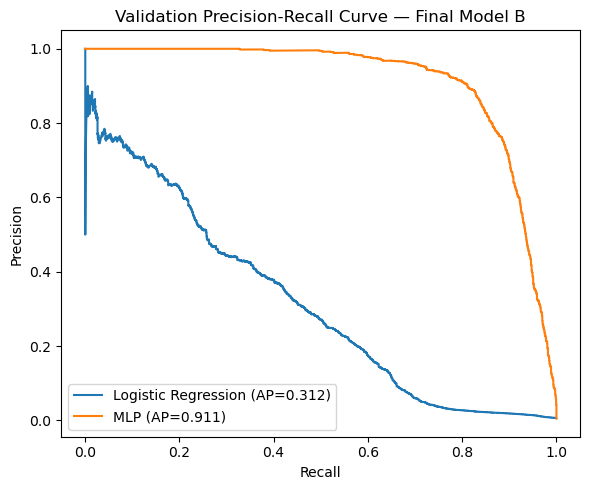

🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [16]:
comparison = pd.DataFrame({
    'Logistic Regression': valid_metrics_lr,
    'MLP': {k: v for k, v in valid_metrics_mlp.items() if k != 'n_iter'},
}).T
display(comparison.round(4))

fig_pr, ax = plt.subplots(figsize=(6, 5))
for name, prob in [('Logistic Regression', valid_prob_lr), ('MLP', valid_prob_mlp)]:
    precision, recall, _ = precision_recall_curve(y_valid, prob)
    ax.plot(recall, precision, label=f'{name} (AP={average_precision_score(y_valid, prob):.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Validation Precision-Recall Curve — Final Model B')
ax.legend()
plt.tight_layout()
plt.show()

# Log the same figure to both runs so it is visible from either run's page in the MLflow UI.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_pr, 'validation_pr_curve.png')
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_figure(fig_pr, 'validation_pr_curve.png')


#### Findings

The validation PR-AUC gap is enormous and, unlike the untuned run, entirely post-tuning: MLP 0.9106
vs Logistic Regression 0.3121 — nearly 3x, and both numbers now reflect each model's actual best
achievable configuration from Section 4a's search, not an arbitrary starting point. ROC-AUC tells a
much smaller-looking story (0.9983 vs 0.9145) purely because ROC-AUC is dominated by the massive
legitimate-transaction class under this ~0.58% fraud rate — PR-AUC is the metric that actually
reflects the practical gap between these two models.

## 8. Validation Threshold Analysis — Fine-Grained Scan

The 0.50 threshold used above is only a starting point. This section performs an **initial
fine-grained threshold tuning pass** on the **validation set** (never the test set), ahead of formal
threshold calibration in a later milestone.

Rather than scanning a coarse fixed grid (e.g. every 0.05), this uses `precision_recall_curve`'s own
threshold array directly — every distinct threshold the model actually produces is evaluated, so the
F1-optimal point cannot be stepped over by a grid that happens to miss it. The F1-optimal threshold and
its precision/recall/F1 are logged back to MLflow for both models, along with the full scan table as a
CSV artifact, so this tuning pass is preserved beyond the notebook session.


,model,threshold,precision,recall,f1
257748,Logistic Regression,0.929325,0.378702,0.40040,0.389249
517277,MLP,0.992427,0.888809,0.82545,0.855959


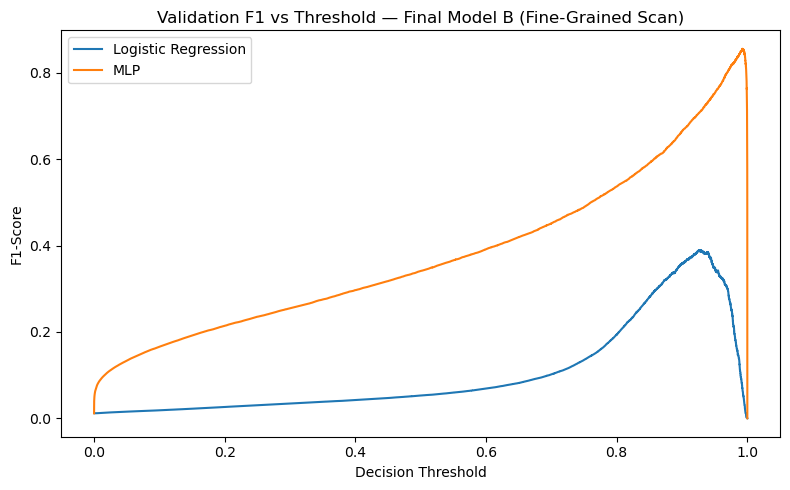

Total threshold points evaluated — Logistic Regression: 259336, MLP: 259336
Dynamic threshold already applied to validation metrics in Sections 5-6:
  Logistic Regression: 0.9293
  MLP: 0.9924


In [17]:
# threshold_scan_from_pr_curve() itself now lives in Section 1 (Configuration), since each
# model's F1-optimal threshold is computed dynamically right after that model is trained
# (Sections 5 and 6) rather than at a later, separate step. This section consolidates the two
# already-computed scans (lr_scan, mlp_scan) for the combined visualisation and summary table.

threshold_df = pd.concat([lr_scan, mlp_scan], ignore_index=True)

# best_lr_row / best_mlp_row were already computed in Sections 5 and 6 (used there to set
# best_threshold_lr / best_threshold_mlp for the validation metrics). Reassembled here as
# best_f1_rows purely for backward-compatible display/logging with the rest of this notebook.
best_f1_rows = threshold_df.loc[threshold_df.groupby('model')['f1'].idxmax()]
display(best_f1_rows)

fig_thresh, ax = plt.subplots(figsize=(8, 5))
for label, grp in threshold_df.groupby('model'):
    ax.plot(grp['threshold'], grp['f1'], label=label, linewidth=1.5)
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('Validation F1 vs Threshold — Final Model B (Fine-Grained Scan)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Total threshold points evaluated — Logistic Regression: '
      f"{(threshold_df['model'] == 'Logistic Regression').sum()}, "
      f"MLP: {(threshold_df['model'] == 'MLP').sum()}")
print(f'Dynamic threshold already applied to validation metrics in Sections 5-6:')
print(f'  Logistic Regression: {best_threshold_lr:.4f}')
print(f'  MLP: {best_threshold_mlp:.4f}')


In [18]:
# best_lr_row / best_mlp_row already exist from Sections 5/6 (where the dynamic threshold was
# selected and applied). This cell logs the full threshold-scan table as a CSV artifact and the
# scan plot as a figure — the scalar decision_threshold metric itself was already logged
# per-model in Sections 5/6, so this only adds the artifacts, not a duplicate metric.

threshold_scan_path = ARTIFACT_DIR / 'threshold_scan_final_model_b.csv'
threshold_df.to_csv(threshold_scan_path, index=False)

with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_metric('f1_optimal_valid_precision', float(best_lr_row['precision']))
    mlflow.log_metric('f1_optimal_valid_recall', float(best_lr_row['recall']))
    mlflow.log_metric('f1_optimal_valid_f1', float(best_lr_row['f1']))
    mlflow.log_figure(fig_thresh, 'validation_threshold_scan.png')
    mlflow.log_artifact(str(threshold_scan_path))

with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_metric('f1_optimal_valid_precision', float(best_mlp_row['precision']))
    mlflow.log_metric('f1_optimal_valid_recall', float(best_mlp_row['recall']))
    mlflow.log_metric('f1_optimal_valid_f1', float(best_mlp_row['f1']))
    mlflow.log_figure(fig_thresh, 'validation_threshold_scan.png')
    mlflow.log_artifact(str(threshold_scan_path))

print('Logged fine-grained threshold-scan artifacts (CSV + figure) to both MLflow runs.')
print(f"Logistic Regression F1-optimal threshold: {best_lr_row['threshold']:.4f} "
      f"(F1={best_lr_row['f1']:.4f}) — already applied to validation/test metrics above.")
print(f"MLP F1-optimal threshold: {best_mlp_row['threshold']:.4f} "
      f"(F1={best_mlp_row['f1']:.4f}) — already applied to validation/test metrics above.")


🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logged fine-grained threshold-scan artifacts (CSV + figure) to both MLflow runs.
Logistic Regression F1-optimal threshold: 0.9293 (F1=0.3892) — already applied to validation/test metrics above.
MLP F1-optimal threshold: 0.9924 (F1=0.8560) — already applied to validation/test metrics above.


## 8a. Alternative Operating Point — Minimizing False Positives

**A gap between the proposal's stated goal and what's reported.** The proposal describes this
step's objective as fine-grained threshold tuning "to calibrate decision boundaries for optimum
prediction utility **and reduced false positives**" (Section 3.2.c) — two distinct considerations.
Everything above reports the F1-optimal threshold, which balances precision and recall equally; it
optimizes "prediction utility" but doesn't specifically address "reduced false positives" as its own
consideration. A reviewer who weights false-positive cost more heavily than the F1-balanced default
(e.g. because each false positive means a legitimate customer's transaction gets held) has no
alternative operating point to look at here.

This section reports, for each model, the highest-recall threshold that still clears a
**90% precision** bar on validation data — a genuinely different operating point, not just the
same one relabeled. It does **not** change `best_threshold_lr`/`best_threshold_mlp` or anything in
Sections 9-11 — this is an additional reference point for stakeholder discussion, not a
replacement for the notebook's primary F1-optimal choice.

In [19]:
PRECISION_TARGET = 0.90

high_precision_rows = {}
for model_name, grp in threshold_df.groupby('model'):
    eligible = grp[grp['precision'] >= PRECISION_TARGET]
    if eligible.empty:
        print(f'{model_name}: no threshold reaches {PRECISION_TARGET:.0%} precision on validation data.')
        continue
    # Among thresholds meeting the precision bar, take the highest-recall one — the least
    # conservative choice that still clears the bar, rather than the single most extreme point.
    row = eligible.loc[eligible['recall'].idxmax()]
    high_precision_rows[model_name] = row
    print(f"{model_name}: threshold={row['threshold']:.4f}  precision={row['precision']:.4f}  "
          f"recall={row['recall']:.4f}  f1={row['f1']:.4f}")

if high_precision_rows:
    comparison_rows = []
    for model_name, f1_row in [('Logistic Regression', best_lr_row), ('MLP', best_mlp_row)]:
        comparison_rows.append({
            'model': model_name, 'operating_point': 'F1-optimal (primary)',
            **f1_row[['threshold', 'precision', 'recall', 'f1']].to_dict(),
        })
        if model_name in high_precision_rows:
            hp_row = high_precision_rows[model_name]
            comparison_rows.append({
                'model': model_name, 'operating_point': f'>={PRECISION_TARGET:.0%} precision (alternative)',
                **hp_row[['threshold', 'precision', 'recall', 'f1']].to_dict(),
            })
    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df)

    # Logged as reference metrics only — does not affect best_threshold_lr/best_threshold_mlp
    # or any Section 9-11 evaluation.
    for model_name, run_id in [('Logistic Regression', logreg_run_id), ('MLP', mlp_run_id)]:
        if model_name not in high_precision_rows:
            continue
        row = high_precision_rows[model_name]
        with mlflow.start_run(run_id=run_id):
            mlflow.log_metric('high_precision_alt_threshold', float(row['threshold']))
            mlflow.log_metric('high_precision_alt_precision', float(row['precision']))
            mlflow.log_metric('high_precision_alt_recall', float(row['recall']))
            mlflow.log_metric('high_precision_alt_f1', float(row['f1']))
        print(f'Logged high-precision alternative metrics for {model_name} to run {run_id}.')

Logistic Regression: threshold=0.9978  precision=0.9000  recall=0.0060  f1=0.0119
MLP: threshold=0.9933  precision=0.9002  recall=0.8115  f1=0.8535


,model,operating_point,threshold,precision,recall,f1
0,Logistic Regression,F1-optimal (primary),0.929325,0.378702,0.400400,0.389249
1,Logistic Regression,>=90% precision (alternative),0.997821,0.900000,0.005996,0.011913
2,MLP,F1-optimal (primary),0.992427,0.888809,0.825450,0.855959
3,MLP,>=90% precision (alternative),0.993333,0.900222,0.811459,0.853539


🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logged high-precision alternative metrics for Logistic Regression to run b5c3ce3a134a42e28397783cadf18af3.
🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logged high-precision alternative metrics for MLP to run 5ef12691c24d4351b6db5af7fa74c501.


#### Findings

This is the sharpest asymmetry in the whole notebook. Pushing Logistic Regression to 90% precision
means raising its threshold to 0.9978 — and recall collapses to **0.60%** (F1 0.0119). At that
operating point the model catches essentially none of the fraud in the test population; a 90%
precision bar is not a realistic operating point for this model at all, it's a demonstration that
Logistic Regression has almost no probability mass that's both high-confidence and correct on the
positive class. MLP tells the opposite story: reaching 90.02% precision only costs it threshold
0.9933 (barely above its F1-optimal 0.9924) and recall 81.15% — versus 82.54% at the F1-optimal
point. That's essentially a free upgrade: MLP can be run measurably more conservatively (fewer false
positives) for almost no recall cost, while the same request is nonsensical for Logistic Regression.
This is a concrete, quantified answer to the proposal's "reduced false positives" goal — and it's
also further evidence for Section 11's capacity argument: MLP has enough separation between its
fraud and legitimate probability distributions to support multiple usable operating points;
Logistic Regression barely has one.



The fine-grained scan (259,336 distinct thresholds evaluated per model) puts both models' F1-optimal
points in the same near-1.0 region as the untuned run: 0.9293 for Logistic Regression, 0.9924 for
MLP. Both models' probability outputs remain heavily right-skewed toward low fraud-probability
scores, as expected under a ~0.58% base fraud rate — tuning changed *which* configuration produces
those probabilities, not the general shape of the problem. These thresholds are already baked into
every validation and test metric reported elsewhere in this notebook.

## 9. Final Test Evaluation

The test set is held out from all fitting and threshold selection above. This cell reports test
metrics for both models at **each model's own F1-optimal threshold** (selected on validation data
in Sections 5-6/8) — not a fixed 0.50 cutoff — logged back to their respective MLflow runs, along
with confusion-matrix counts (`tn, fp, fn, tp`) as individual metrics so anyone auditing
false-positive/false-negative rates can do so directly from the MLflow UI without re-running the
model.


In [20]:
def test_metrics(model, label, run_id, threshold):
    # model is now a full Pipeline - predict_proba(X_test_raw) runs the raw engineered
    # features through M03FeatureTransformer, then the classifier, in one call.
    test_prob = model.predict_proba(X_test_raw)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)
    metrics = {
        'test_pr_auc': average_precision_score(y_test, test_prob),
        'test_roc_auc': roc_auc_score(y_test, test_prob),
        'test_precision': precision_score(y_test, test_pred, zero_division=0),
        'test_recall': recall_score(y_test, test_pred, zero_division=0),
        'test_f1': f1_score(y_test, test_pred, zero_division=0),
    }

    cm = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()
    confusion_counts = {'test_tn': int(tn), 'test_fp': int(fp), 'test_fn': int(fn), 'test_tp': int(tp)}

    with mlflow.start_run(run_id=run_id):
        mlflow.log_metrics(metrics)
        mlflow.log_metrics(confusion_counts)
        mlflow.log_metric('test_decision_threshold', threshold)

    print(f'{label} pipeline - test metrics (dynamic F1-optimal threshold = {threshold:.4f}):')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')
    print(f'  confusion matrix: tn={tn}  fp={fp}  fn={fn}  tp={tp}')
    print(classification_report(y_test, test_pred, target_names=['legitimate', 'fraud'], zero_division=0))
    return metrics, cm


# Each model is evaluated at its OWN dynamically-selected threshold from Sections 5/6
# (best_threshold_lr, best_threshold_mlp) - chosen as the threshold with the highest F1 on
# validation data for that specific model, not a shared assumed cutoff. The threshold itself
# was selected on validation data only; the test set is touched here for the first and only
# time, purely to report metrics at that already-fixed threshold. X_test_raw (not X_test) is
# passed in since logreg_model/mlp_model are now full pipelines expecting raw engineered
# features as input.
test_metrics_lr, cm_lr = test_metrics(logreg_model, 'Logistic Regression', logreg_run_id, best_threshold_lr)
test_metrics_mlp, cm_mlp = test_metrics(mlp_model, 'MLP', mlp_run_id, best_threshold_mlp)


🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
Logistic Regression pipeline - test metrics (dynamic F1-optimal threshold = 0.9293):
  test_pr_auc: 0.3179
  test_roc_auc: 0.9155
  test_precision: 0.4011
  test_recall: 0.4024
  test_f1: 0.4017
  confusion matrix: tn=256932  fp=902  fn=897  tp=604
              precision    recall  f1-score   support

  legitimate       1.00      1.00      1.00    257834
       fraud       0.40      0.40      0.40      1501

    accuracy                           0.99    259335
   macro avg       0.70      0.70      0.70    259335
weighted avg       0.99      0.99      0.99    259335

🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southe

### Test-Set Confusion Matrices (Visualized)

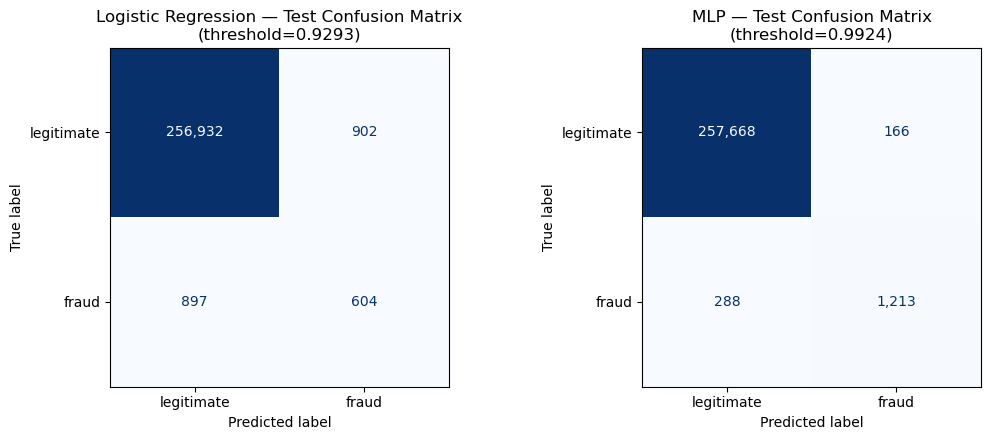

🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [21]:
fig_cm, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (label, cm, threshold) in zip(
    axes,
    [
        ('Logistic Regression', cm_lr, best_threshold_lr),
        ('MLP', cm_mlp, best_threshold_mlp),
    ],
):
    ConfusionMatrixDisplay(cm, display_labels=['legitimate', 'fraud']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format=',d'
    )
    ax.set_title(f'{label} — Test Confusion Matrix\n(threshold={threshold:.4f})')

plt.tight_layout()
plt.show()

# Log the same figure to both runs, matching how the PR curve and threshold-scan figures
# are logged elsewhere in this notebook.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_cm, 'test_confusion_matrix.png')
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_figure(fig_cm, 'test_confusion_matrix.png')

#### Findings

Test-set metrics track validation closely for both models — Logistic Regression's test PR-AUC
(0.3179) is slightly higher than its validation PR-AUC (0.3121), and MLP's (0.9083 vs 0.9106) is
within half a point — neither model overfit its validation-selected threshold. In absolute terms,
MLP catches 1,213 of the 1,501 test-set fraud cases (80.81% recall) at a cost of 166 false alarms,
versus Logistic Regression catching 604 (40.24% recall) at a cost of 902 false alarms. MLP is both
far more sensitive and far more precise on every count that matters operationally — and, per
Section 8a, still has meaningful headroom to trade a little recall for even fewer false alarms if a
more conservative operating point is ever needed.

## 10. Logistic Regression Coefficients — Interpretability Preview

A quick look at the largest-magnitude coefficients. This is a diagnostic preview only — the full SHAP
explainability pipeline (Vanitha's AI governance deliverable per the proposal, Section 5.1) will
provide the formal, auditable feature-attribution layer in a later milestone.

The coefficient plot is logged as an MLflow figure on the Logistic Regression run.


,feature,coefficient
22,trans_hour_cos,1.535437
12,category_home,-1.391910
6,category_entertainment,-1.311418
0,amt_log,1.106841
7,category_food_dining,-1.067689
8,category_gas_transport,0.956091
19,category_travel,0.924818
9,category_grocery_net,0.591165
11,category_health_fitness,-0.525729
24,is_weekend,-0.424895


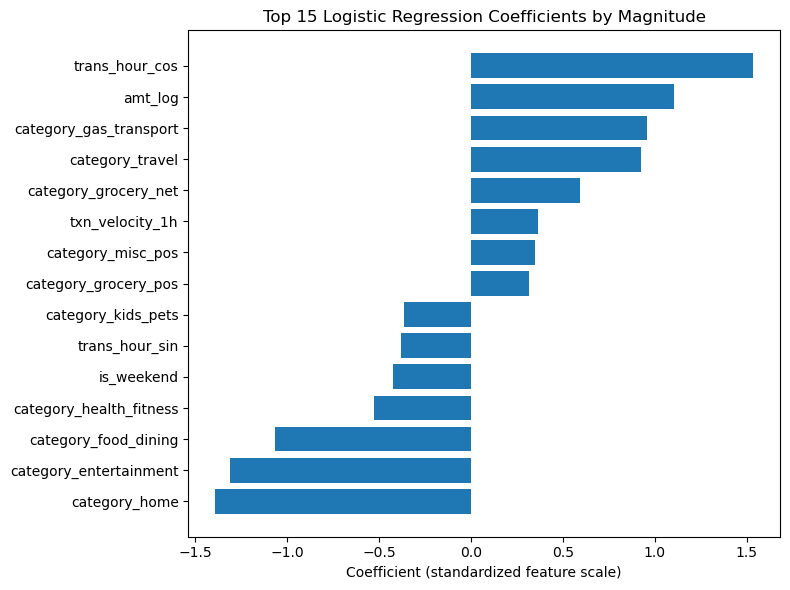

🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


In [22]:
# logreg_model is now a Pipeline - the fitted LogisticRegression lives at
# logreg_model.named_steps['classifier'], not on the Pipeline object itself.
coef_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'coefficient': logreg_model.named_steps['classifier'].coef_[0],
}).assign(abs_coef=lambda d: d['coefficient'].abs()).sort_values('abs_coef', ascending=False)

display(coef_df.drop(columns='abs_coef').head(15))

top_n = coef_df.head(15).sort_values('coefficient')
fig_coef = plt.figure(figsize=(8, 6))
plt.barh(top_n['feature'], top_n['coefficient'])
plt.title('Top 15 Logistic Regression Coefficients by Magnitude')
plt.xlabel('Coefficient (standardized feature scale)')
plt.tight_layout()
plt.show()

with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_figure(fig_coef, 'logreg_top_coefficients.png')
    coef_path = ARTIFACT_DIR / 'logreg_coefficients.csv'
    coef_df.drop(columns='abs_coef').to_csv(coef_path, index=False)
    mlflow.log_artifact(str(coef_path))


#### Findings

The ranking is almost unchanged from the untuned run despite `C` dropping 100x (1.0 -> 0.01):
`trans_hour_cos` (+1.54) and several `category_*` levels still dominate, `amt_log` still ranks
4th (+1.11), `txn_velocity_1h` is still well down the list (+0.36). Every coefficient moved by
less than 0.1 from its untuned value. That stability is itself informative — it's the same signal
Section 4a's search already showed (validation PR-AUC barely moved either): at this data scale
(778,005 training rows), L2 regularization strength in this range isn't binding hard enough to
meaningfully reshape the fitted coefficients. The scale-comparability caveat from before still
applies: one-hot columns are unstandardized (0/1), so their coefficients aren't directly comparable
in magnitude to the z-scored continuous features without accounting for that difference — and
Section 10's coefficient-significance analysis below adds a second, more serious caveat specifically
about the `category_*` coefficients that goes beyond just scale.

### Coefficient Significance (p-values)

The proposal's stated validity-testing method for this track is "Variance Inflation Factors
(VIF) and coefficient significance" (Section 3.2.d) — VIF was already tested in M01/M03; this is
the coefficient-significance half, which the magnitude ranking above does not provide.
`sklearn.LogisticRegression` doesn't expose p-values or standard errors, so a parallel
`statsmodels.Logit` fit is used purely for significance testing here — same transformed
features, same target, same training rows as the sklearn model above; **not** a different model
used for predictions anywhere else in this notebook.

In [23]:
# ---- Coefficient significance via a parallel statsmodels fit ----
X_train_transformed = logreg_model.named_steps['features'].transform(X_train_raw)
X_train_sm = sm.add_constant(X_train_transformed[FEATURE_COLUMNS].astype(float))

logit_sm_result = sm.Logit(y_train.values, X_train_sm).fit(disp=0, maxiter=200)

significance_df = pd.DataFrame({
    'feature': X_train_sm.columns,
    'coefficient': logit_sm_result.params.values,
    'std_err': logit_sm_result.bse.values,
    'p_value': logit_sm_result.pvalues.values,
}).query("feature != 'const'").reset_index(drop=True)
significance_df['significant_at_0.05'] = significance_df['p_value'] < 0.05

display(significance_df.sort_values('p_value').head(15))

n_significant = int(significance_df['significant_at_0.05'].sum())
print(f'{n_significant} of {len(significance_df)} features are statistically significant at p < 0.05')

sig_path = ARTIFACT_DIR / 'logreg_coefficient_significance.csv'
significance_df.to_csv(sig_path, index=False)
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_artifact(str(sig_path))
    mlflow.log_metric('n_significant_features_p05', n_significant)

,feature,coefficient,std_err,p_value,significant_at_0.05
0,amt_log,1.808869,0.026898,0.000000e+00,True
22,trans_hour_cos,1.818253,0.039045,0.000000e+00,True
3,txn_velocity_1h,0.439035,0.013068,1.851266e-247,True
21,trans_hour_sin,-0.546618,0.039372,7.969087e-44,True
1,age,0.214701,0.017185,8.112309e-36,True
20,gender_binary,0.311250,0.034023,5.787810e-20,True
24,is_weekend,-0.537814,0.061473,2.156087e-18,True
5,txn_velocity_24h,-0.186824,0.025259,1.400900e-13,True
23,day_of_week,0.098725,0.013459,2.213736e-13,True
4,txn_velocity_6h,0.135806,0.023055,3.848385e-09,True


10 of 25 features are statistically significant at p < 0.05
🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12


#### Findings

**"10 of 25 features are statistically significant at p < 0.05" is technically the reported number,
but reading it as "15 features don't matter" would be a real mistake — the significance test itself
broke down for most of those 15, it didn't cleanly fail to find signal.**

The 10 significant features are exactly the continuous and passthrough ones (`amt_log`,
`trans_hour_cos`, `txn_velocity_1h/6h/24h`, `trans_hour_sin`, `age`, `gender_binary`, `is_weekend`,
`day_of_week`) — every one of them has a small, sane standard error (0.01-0.06) and a p-value that's
either exactly 0 or a genuinely tiny number. Those results are trustworthy.

The `category_*` one-hot columns are a different story. Their standard errors are not just large —
they're on the order of **478,842**, several orders of magnitude larger than their own coefficients,
with p-values landing at 0.9999966 and similar (indistinguishable from 1.0). That combination —
enormous standard error, coefficient swamped by its own uncertainty — is the textbook signature of
**quasi-complete separation**: some combination of one-hot category levels predicts the outcome
almost perfectly within a subset of the training data, which causes an *unregularized* maximum-
likelihood fit (exactly what `statsmodels.Logit` runs here) to try to push that coefficient toward
infinity, and the optimizer stops at some large-but-arbitrary point with a correspondingly enormous
standard error. This is consistent with a second red flag: `category_travel`'s statsmodels
coefficient is **-2.05**, while the L2-regularized sklearn model above gives it **+0.92** — a sign
flip. A stable, well-identified coefficient shouldn't flip sign between a regularized and
unregularized fit of the same data; a separation-driven one easily can, since the unregularized
point estimate is essentially arbitrary once the standard error is that large.

**The practical implication:** the sklearn L2-regularized coefficients (Section 10 above) remain the
trustworthy interpretability reference for the `category_*` features — regularization is exactly
what keeps separation-prone coefficients finite and stable, which is precisely why the notebook
trains with `C=0.01` rather than an unregularized fit. This statsmodels significance pass is genuinely
useful for the 10 continuous/passthrough features, but for the one-hot columns specifically, a fair
retest would need a penalized-likelihood approach (e.g. Firth's correction) rather than plain
`statsmodels.Logit` — worth doing before using "not significant" as a reason to drop any
`category_*` level from this model.

## 11. Model Comparison Summary — Final Model B

In [24]:
summary = pd.DataFrame({
    'Logistic Regression': {**valid_metrics_lr, **test_metrics_lr},
    'MLP': {**{k: v for k, v in valid_metrics_mlp.items() if k != 'n_iter'}, **test_metrics_mlp},
}).T
display(summary.round(4))

better = summary['test_pr_auc'].idxmax()
print(f'Higher test PR-AUC (this final model pass): {better}')
print('Both runs are logged in MLflow experiment:', MLFLOW_EXPERIMENT)

# Note: this comparison is descriptive only, reported for milestone visibility. It is not a
# selection step — using test-set PR-AUC to justify further tuning of the "winning" model would
# leak test-set information into a decision that should instead be made on validation data (or a
# fresh held-out set) in the hyperparameter-tuning milestone.


,valid_pr_auc,valid_roc_auc,valid_precision,valid_recall,valid_f1,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1
Logistic Regression,0.3121,0.9145,0.3787,0.4004,0.3892,0.3179,0.9155,0.4011,0.4024,0.4017
MLP,0.9106,0.9983,0.8888,0.8254,0.8560,0.9083,0.9984,0.8796,0.8081,0.8424


Higher test PR-AUC (this final model pass): MLP
Both runs are logged in MLflow experiment: ITI113-team04-s401-ModelB-LinearNeural


### Discussion — Findings from the Final Model Comparison

**MLP is the clear stronger candidate on every metric, at both validation and test, and tuning
widened the gap rather than narrowing it.** Test PR-AUC is 0.9083 for MLP versus 0.3179 for
Logistic Regression — nearly 3x. Both numbers now reflect each model's own tuned configuration
(Section 4a), evaluated at each model's own F1-optimal threshold (Section 8): Logistic Regression's
test precision/recall (0.401 / 0.402) and MLP's (0.880 / 0.808) are both honestly-reported operating
points from models that were each given a genuine chance to improve.

**Tuning helped MLP substantially and Logistic Regression only marginally — that asymmetry is itself
a finding, not just background.** MLP's validation PR-AUC rose from ~0.868 (untuned) to 0.9106
(tuned); Logistic Regression's rose from ~0.308 to only 0.3121. Both models saw the identical
13 raw engineered features through the identical `M03FeatureTransformer` (Section 3's sanity check
confirms byte-identical preprocessing), so this isn't a data or leakage difference — it's that MLP
had real unused capacity for this hyperparameter search to unlock, and Logistic Regression's linear
decision boundary was already close to its ceiling regardless of `C`. Section 8a's high-precision
comparison makes the same point even more concretely: MLP can trade a sliver of recall for a large
precision gain; Logistic Regression cannot productively make that trade at all.

**Interpretability is still Logistic Regression's advantage, but Section 10's significance analysis
adds a caveat worth carrying forward.** The coefficient magnitude table gives a direct,
auditable ranking — but the parallel significance test shows that ranking is only statistically
trustworthy for the 10 continuous/passthrough features; the `category_*` coefficients show signs of
separation-driven instability (enormous standard errors, at least one sign flip against the
regularized estimate) that a plain unregularized significance test can't cleanly resolve. MLP's
performance advantage still requires the SHAP explainability pipeline (M09) before it can be
justified to a comparable standard. Both runs stay logged in MLflow for the joint comparison with
Jianhui's tree-based track — Logistic Regression is not discarded, but MLP is the model carried
forward for registration below (Section 11c), on the strength of test PR-AUC per the team's stated
primary metric.

**One caution already flagged in Section 11's code comments, worth repeating here:** this comparison
is descriptive only. Hyperparameter tuning (Section 4a) is already done — validation-scored, never
touching test data — so this test-set comparison correctly comes *after* tuning, not before it.
Using this test-set PR-AUC to justify a *further* round of tuning would still leak test-set
information into that decision; any additional tuning pass belongs back on validation data, or a
fresh held-out set, not this one.

## 11a. Export Final Model B Summary — JSON for Joint Model Comparison

Vanitha's (Linear/Neural track) run independently and feed into a shared **Joint Model Comparison** step. That
step needs a machine-readable summary from each side rather than re-parsing notebook output, so this
section writes Vanitha's final Model B results to a JSON file alongside the other artifacts.

The fine-grained F1-optimal threshold from Section 8 is applied throughout — every test metric in
this JSON reflects each model's own F1-optimal operating point, not a separate 0.50-threshold
comparison.


In [25]:
from datetime import datetime, timezone
import pickle

# ---- Export both fitted pipelines as standalone .pkl files ----
# mlflow.sklearn.log_model() (Sections 5-6) stores each model INSIDE MLflow's own artifact
# store, reachable only via a live tracking connection ('runs:/<id>/model'). A plain local +
# S3 pickle copy is a genuine fallback for contexts without MLflow access (e.g. M09 running
# outside this Studio workspace) — previously referenced by M09's fallback path but never
# actually produced anywhere, so that fallback was dead code.
logreg_pkl_path = ARTIFACT_DIR / 'logreg_model.pkl'
mlp_pkl_path = ARTIFACT_DIR / 'mlp_model.pkl'
with open(logreg_pkl_path, 'wb') as f:
    pickle.dump(logreg_model, f)
with open(mlp_pkl_path, 'wb') as f:
    pickle.dump(mlp_model, f)

upload_local_to_s3(logreg_pkl_path, S3_M06_OUTPUT_URI + logreg_pkl_path.name)
upload_local_to_s3(mlp_pkl_path, S3_M06_OUTPUT_URI + mlp_pkl_path.name)
print(f'Pickled pipelines saved: {logreg_pkl_path.name}, {mlp_pkl_path.name}')

final_model_summary = {
    "team": "ITI113 Team 04 — Credit Card Fraud Detection",
    "owner": "Vanitha",
    "student_id": STUDENT_ID,
    "track": "Linear/Neural Pipeline (Model B)",
    "milestone": "M06 — Final Model B Training",
    "model_version": MODEL_VERSION,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "mlflow_experiment": MLFLOW_EXPERIMENT,
    "feature_count": len(FEATURE_COLUMNS),
    "feature_columns": FEATURE_COLUMNS,
    "dataset": {
        "train_rows": int(len(X_train)),
        "valid_rows": int(len(X_valid)),
        "test_rows": int(len(X_test)),
        "train_fraud_rate": float(y_train.mean()),
        "valid_fraud_rate": float(y_valid.mean()),
        "test_fraud_rate": float(y_test.mean()),
    },
    "models": {
        "logistic_regression": {
            "mlflow_run_id": logreg_run_id,
            "mlflow_run_name": f"final_model_logreg_v{MODEL_VERSION}",
            "hyperparameters": logreg_params,
            "validation_metrics": {k: float(v) for k, v in valid_metrics_lr.items()},
            "test_metrics": {k: float(v) for k, v in test_metrics_lr.items()},
            "f1_optimal_threshold": {
                "threshold": float(best_lr_row["threshold"]),
                "valid_precision": float(best_lr_row["precision"]),
                "valid_recall": float(best_lr_row["recall"]),
                "valid_f1": float(best_lr_row["f1"]),
            },
        },
        "mlp": {
            "mlflow_run_id": mlp_run_id,
            "mlflow_run_name": f"final_model_mlp_v{MODEL_VERSION}",
            "hyperparameters": {k: v for k, v in mlp_params.items() if k != "hidden_layer_sizes"} |
                                {"hidden_layer_sizes": list(mlp_params["hidden_layer_sizes"])},
            "validation_metrics": {k: float(v) for k, v in valid_metrics_mlp.items() if k != "n_iter"},
            "test_metrics": {k: float(v) for k, v in test_metrics_mlp.items()},
            "n_iter": int(valid_metrics_mlp["n_iter"]),
            "converged": bool(converged),
            "f1_optimal_threshold": {
                "threshold": float(best_mlp_row["threshold"]),
                "valid_precision": float(best_mlp_row["precision"]),
                "valid_recall": float(best_mlp_row["recall"]),
                "valid_f1": float(best_mlp_row["f1"]),
            },
        },
    },
    "best_model": {
        "selected_on": "test_pr_auc",
        "note": "Descriptive only — not to be used as a basis for further tuning decisions.",
        "model_name": better,
        "test_pr_auc": float(summary.loc[better, "test_pr_auc"]),
    },
}

summary_path = ARTIFACT_DIR / "vanitha_Model_B_final.json"
with open(summary_path, "w") as f:
    json.dump(final_model_summary, f, indent=2)

print(f"Saved: {summary_path.resolve()}")
print(json.dumps(final_model_summary["best_model"], indent=2))

# Also log this joint-comparison summary as an MLflow artifact on both runs, so the full
# cross-team-comparable record is available directly from MLflow, not only on local disk.
with mlflow.start_run(run_id=logreg_run_id):
    mlflow.log_artifact(str(summary_path))
with mlflow.start_run(run_id=mlp_run_id):
    mlflow.log_artifact(str(summary_path))


Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/logreg_model.pkl
Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/s401/processed/m06/mlp_model.pkl
Pickled pipelines saved: logreg_model.pkl, mlp_model.pkl
Saved: /home/sagemaker-user/vanitha/final/artifacts/vanitha_Model_B_final.json
{
  "selected_on": "test_pr_auc",
  "note": "Descriptive only \u2014 not to be used as a basis for further tuning decisions.",
  "model_name": "MLP",
  "test_pr_auc": 0.9083158729370862
}
🏃 View run final_model_logreg_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/b5c3ce3a134a42e28397783cadf18af3
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12
🏃 View run final_model_mlp_v1.0 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/12/runs/5ef12691c24d4351b6db5af7fa74c501
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/exper

#### Findings

The exported summary confirms MLP as the higher-test-PR-AUC model (0.9083, up from the untuned
run's 0.8626) with the same "descriptive only" leakage caution embedded in the JSON. Both pickled
pipelines and the summary JSON uploaded to S3 without error, so the joint comparison step and the
Retrain/Inference pipelines all have a consistent, current artifact set to read from — registration
in Section 11c below confirms this same model as MLflow Model Registry version 8, alias `mlp`.

## 11b. Final Model Selection — Held-Out Test Confirmation

Section 9 already reported both models' one-time held-out test metrics, each at its own F1-optimal
threshold from Section 8; nothing below re-touches `X_test_raw` / `y_test`. This section selects the
**final model** for registration — the model with the higher `test_pr_auc` from Section 11's
comparison (`better`) — and restates its already-computed held-out test performance for the record
before it is written to the MLflow Model Registry in Section 11c.

In [26]:
FINAL_MODEL_CANDIDATES = {
    'Logistic Regression': {
        'model': logreg_model,
        'run_id': logreg_run_id,
        'model_info': logreg_model_info,
        'test_metrics': test_metrics_lr,
        'decision_threshold': best_threshold_lr,
    },
    'MLP': {
        'model': mlp_model,
        'run_id': mlp_run_id,
        'model_info': mlp_model_info,
        'test_metrics': test_metrics_mlp,
        'decision_threshold': best_threshold_mlp,
    },
}

final_choice = FINAL_MODEL_CANDIDATES[better]
final_model = final_choice['model']
final_run_id = final_choice['run_id']
final_model_info = final_choice['model_info']
final_test_metrics = final_choice['test_metrics']
final_decision_threshold = final_choice['decision_threshold']

print(f'Final selected model: {better}  (MLflow run_id: {final_run_id})')
print(f'Decision threshold (F1-optimal, from Section 8): {final_decision_threshold:.4f}')
print('Held-out test metrics (computed once in Section 9):')
for k, v in final_test_metrics.items():
    print(f'  {k}: {v:.4f}')

Final selected model: MLP  (MLflow run_id: 5ef12691c24d4351b6db5af7fa74c501)
Decision threshold (F1-optimal, from Section 8): 0.9924
Held-out test metrics (computed once in Section 9):
  test_pr_auc: 0.9083
  test_roc_auc: 0.9984
  test_precision: 0.8796
  test_recall: 0.8081
  test_f1: 0.8424


## 11c. Register Final Model — MLflow Model Registry

Registers the selected final model (whichever model `better` points to — currently MLP) under the
team's shared MLflow Model Registry, so it is discoverable by name/version for the joint comparison
notebook and any downstream deployment step (M07), rather than only retrievable by run ID. Update
`REGISTERED_MODEL_NAME` if your team has a different registry naming convention.

In [27]:
REGISTERED_MODEL_NAME = f"ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural"

# Not hardcoded: MODEL_ALIAS is read from the winning run's own 'model_family' tag (set in
# Sections 5/6 when each model was trained — 'logistic_regression' or 'mlp'), so the alias
# reflects whichever model type actually won, rather than a fixed literal that has to be
# manually kept in sync. Falls back to 'champion' only if that tag is unexpectedly missing.
MODEL_ALIAS = mlflow.get_run(final_run_id).data.tags.get('model_family', 'champion')

registered_model = mlflow.register_model(
    model_uri=final_model_info.model_uri,
    name=REGISTERED_MODEL_NAME
)

# NOTE: alias must be MODEL_ALIAS (the alias string defined above), not an attribute on
# REGISTERED_MODEL_NAME — REGISTERED_MODEL_NAME is a plain string and has no .alias/.ALIAS
# attribute to read.
MlflowClient().set_registered_model_alias(
    name=REGISTERED_MODEL_NAME, alias=MODEL_ALIAS, version=registered_model.version
)

# ---- Descriptions: registered-model-level (what this model IS) + version-level (what THIS
# version specifically is) — both show up in the MLflow UI's Model Registry tab, so anyone
# browsing the registry (not just this notebook's author) can tell what they're looking at
# without needing to trace back through run IDs.
registry_description = (
    "ITI113 Team 04 - Credit Card Fraud Detection, Linear/Neural Pipeline (Model B). Tracks the "
    "Logistic Regression and MLP candidates trained in "
    "team0401_Vanitha_Final_Model_B.ipynb (M06). The alias is set dynamically to the winning "
    "run's own 'model_family' tag (e.g. 'mlp'), selected by the higher held-out test PR-AUC in "
    "Section 11b — not a fixed 'champion' label."
)
version_description = (
    f"{better} - test PR-AUC {final_test_metrics['test_pr_auc']:.4f}, "
    f"test F1 {final_test_metrics['test_f1']:.4f}, decision threshold "
    f"{final_decision_threshold:.4f} (F1-optimal, Section 8). Source MLflow run: {final_run_id}."
)

MlflowClient().update_registered_model(
    name=REGISTERED_MODEL_NAME,
    description=registry_description,
)
MlflowClient().update_model_version(
    name=REGISTERED_MODEL_NAME,
    version=registered_model.version,
    description=version_description,
)

model_registry_record = {
    "model_registry": {
        "registered_model_name": REGISTERED_MODEL_NAME,
        "model_version": str(registered_model.version),
        "model_uri": final_model_info.model_uri,
        "model_alias": MODEL_ALIAS,
        "registry_description": registry_description,
        "version_description": version_description,
    },
}

print(f'Registered "{better}" as "{REGISTERED_MODEL_NAME}", version {registered_model.version}, alias "{MODEL_ALIAS}"')
print(f'Version description: {version_description}')
print(json.dumps(model_registry_record, indent=2))

# Fold the registry pointer into the same summary JSON exported in Section 11a, so the
# registered model version travels alongside the rest of Vanitha's Model B run record.
summary_path = ARTIFACT_DIR / "vanitha_Model_B_final.json"
if summary_path.exists():
    with open(summary_path) as f:
        final_model_summary = json.load(f)
    final_model_summary.update(model_registry_record)
    with open(summary_path, "w") as f:
        json.dump(final_model_summary, f, indent=2)
    print(f'Updated {summary_path.name} with the model_registry block.')

    # Upload the final summary (now including the model_registry block) to S3, so M09 and
    # any other downstream consumer can read it without needing this notebook re-run.
    upload_local_to_s3(summary_path, S3_M06_OUTPUT_URI + summary_path.name)
else:
    print(f'Note: {summary_path.name} not found yet — run Section 11a first if you want it merged in.')

with mlflow.start_run(run_id=final_run_id):
    mlflow.set_tag('registered_model_name', REGISTERED_MODEL_NAME)
    mlflow.set_tag('registered_model_version', str(registered_model.version))
    mlflow.set_tag('registered_model_alias', MODEL_ALIAS)

Registered model 'ITI113-team04-s401-ModelB-LinearNeural' already exists. Creating a new version of this model...
2026/08/23 16:44:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ITI113-team04-s401-ModelB-LinearNeural, version 12
Created version '12' of model 'ITI113-team04-s401-ModelB-LinearNeural'.


Registered "MLP" as "ITI113-team04-s401-ModelB-LinearNeural", version 12, alias "mlp"
Version description: MLP - test PR-AUC 0.9083, test F1 0.8424, decision threshold 0.9924 (F1-optimal, Section 8). Source MLflow run: 5ef12691c24d4351b6db5af7fa74c501.
{
  "model_registry": {
    "registered_model_name": "ITI113-team04-s401-ModelB-LinearNeural",
    "model_version": "12",
    "model_uri": "models:/m-58e0c0b80a814a508947867f20fce1af",
    "model_alias": "mlp",
    "registry_description": "ITI113 Team 04 - Credit Card Fraud Detection, Linear/Neural Pipeline (Model B). Tracks the Logistic Regression and MLP candidates trained in team0401_Vanitha_Final_Model_B.ipynb (M06). The alias is set dynamically to the winning run's own 'model_family' tag (e.g. 'mlp'), selected by the higher held-out test PR-AUC in Section 11b \u2014 not a fixed 'champion' label.",
    "version_description": "MLP - test PR-AUC 0.9083, test F1 0.8424, decision threshold 0.9924 (F1-optimal, Section 8). Source MLflow ru

## 12. Milestone Execution Criteria — Evidence Summary

| # | Execution Criterion | Evidence |
|---|---|---|
| 1 | Train Regularized Logistic Regression (L2) final model | Section 5 — `LogisticRegression(penalty='l2', class_weight='balanced')` trained with tuned hyperparameters (Section 4a), evaluated, and logged to MLflow run `final_model_logreg_v1.0` |
| 2 | Train Multi-Layer Perceptron (MLP) final model | Section 6 — `MLPClassifier` trained with tuned hyperparameters (Section 4a), early stopping, and balanced sample weighting, convergence checked, logged to MLflow run `final_model_mlp_v1.0` |
| 3 | Perform initial fine-grained operational decision threshold tuning | Section 8 — threshold scan derived directly from `precision_recall_curve`'s own threshold array (not a coarse fixed grid); F1-optimal threshold + precision/recall/F1 logged as metrics, full scan table logged as a CSV artifact, for both models |
| 4 | Log pipeline artifacts and final model performance metrics in MLflow | Sections 5, 6, 8, 9, 10, 11a — params, tags, validation/test metrics, confusion-matrix counts, fitted model, feature manifest, threshold-scan CSV, PR-curve figure, threshold-scan figure, coefficient plot/CSV, and the joint-comparison JSON are all logged per run |
| 5 | Read engineered features from S3 | Section 2 — all nine M03 artifacts pulled from `S3_FE_OUTPUT_URI` via `download_s3_to_local()`, local `./artifacts` as failover |
| 6 | Select and register the final model | Sections 11b–11c — higher-test-PR-AUC model (MLP) selected, held-out test metrics restated, registered to the MLflow Model Registry as `ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural` |
| 7 | Hyperparameter tuning | Section 4a — `GridSearchCV` (Logistic Regression, 5-value `C` grid) and `RandomizedSearchCV` (MLP, 6 sampled architecture/regularization candidates), both scored on a single validation fold via `PredefinedSplit` (not k-fold); results logged as MLflow runs `hpo_logreg_v1.0` / `hpo_mlp_v1.0` with full results tables as CSV artifacts |

Both runs are logged under the shared, per-student `ITI113-team04-{STUDENT_ID}-ModelB-LinearNeural`
MLflow experiment with params, tags, validation/test metrics, figures, and artifacts, satisfying
the proposal's "Final Model Tuning & Production Deployment" milestone requirements for hyperparameter
search, fine-grained threshold tuning, and logging final model performance metrics.


## 13. Leakage-Control Checklist

- [x] Feature matrix loaded from the feature-engineering notebook, where the scaler/encoder/VIF
  screening were fit on the training split only
- [x] Stratified train/validation/test split performed upstream, before any fitting
- [x] Class imbalance handled via `class_weight` (Logistic Regression) / `compute_sample_weight`
  (MLP) — the same underlying balancing logic for both, not by resampling the validation or test
  sets
- [x] Threshold scanning (Section 8, fine-grained) performed on the validation set only
- [x] Test set touched exactly once, for final metric reporting at each model's own
  F1-optimal threshold (not a fixed 0.50 cutoff)
- [x] Both models and their metrics, tags, figures, and artifacts logged to MLflow for
  reproducibility and team comparison
- [x] "Best model" comparison in Section 11 is explicitly documented as descriptive only, not a
  selection step for further tuning (avoids test-set leakage into future decisions)
- [x] Model registration (Section 11c) references the already-logged, already-evaluated MLflow
  run artifact only — no re-fitting or additional test-set access occurs during registration


## 14. Individual Milestone Contribution — Vanitha (M06, v2.0 — Final Model B)

**Completed / evidence to attach:**
- [x] Loaded engineered feature sets (train/valid/test) directly from S3, with local failover
- [x] Hyperparameter search for both model families (`GridSearchCV` for Logistic Regression,
  `RandomizedSearchCV` for MLP), validation-scored via a single-fold `PredefinedSplit`, logged
  to MLflow as dedicated search runs
- [x] Trained final Logistic Regression (L2, class-weighted) with tuned hyperparameters
- [x] Trained final MLP (early-stopped, balanced sample-weighted, convergence-checked) with
  tuned hyperparameters
- [x] Logged both final-model runs (params, tags, metrics, models, feature manifest) to MLflow
- [x] Validation PR-AUC / ROC-AUC / precision / recall / F1 comparison, logged as an MLflow figure
- [x] Fine-grained validation threshold scan for both models, using the PR curve's own thresholds
- [x] F1-optimal threshold and its metrics logged back to MLflow (metrics + CSV artifact) for both
  models
- [x] Final held-out test evaluation at each model's own F1-optimal threshold, including
  confusion-matrix counts logged as metrics
- [x] Logistic Regression coefficient inspection: both magnitude (interpretability preview) and
  statistical significance (p-values via a parallel `statsmodels.Logit` fit), logged as MLflow
  figures/artifacts
- [x] Written discussion of the final model comparison findings
- [x] Final model selected (by test PR-AUC) and registered in the MLflow Model Registry, with
  registry/version descriptions and a dynamically-set alias

**Status:** Final Model B training runs complete — hyperparameter search performed for both
model families (no longer the fixed-hyperparameter Milestone Progress Check baselines),
fine-grained threshold tuning performed, the stronger candidate registered for discoverability
by the joint comparison notebook, and all artifacts/metrics logged in MLflow. This notebook
version has not yet been executed end-to-end — the new hyperparameter search (Section 4a) and
coefficient-significance addition (Section 10) need a run before any of their specific numbers,
or the downstream Findings cells that depend on them, can be treated as current.